## Figures for IRES seminar on 2024-12-05

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

In [3]:
# read in summer stats
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_ALL_summer_stats.nc'
ds_full = xr.open_dataset(input_path)

# generate weights for any spatial averages
# (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_full.lat))
weights.name = "weights"

# Summer Length Data
ds_full_length = ds_full.SummerLength

### Data for violin plots

In [4]:
ds_base = ds_full_length.sel(time=slice('1961','1990'))
ds = ds_full_length.sel(time=slice('1994','2023'))

Van p-val: 0.0001
Tor p-val: 0.0041
Bei p-val: 0.0
Gua p-val: 0.0002
Syd p-val: 0.0014
CTn p-val: 0.2158
Phx p-val: 0.0
NwD p-val: 0.0842


(20.0, 150.0)

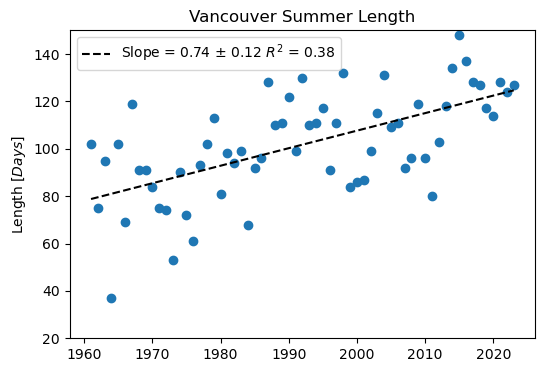

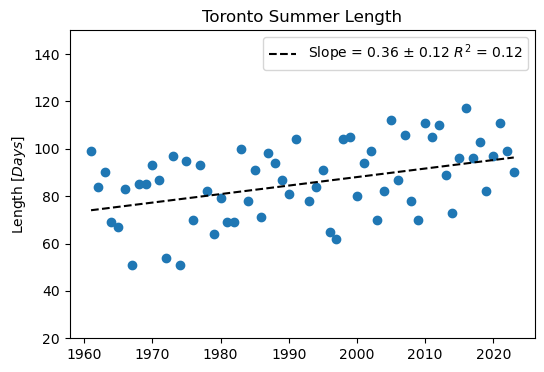

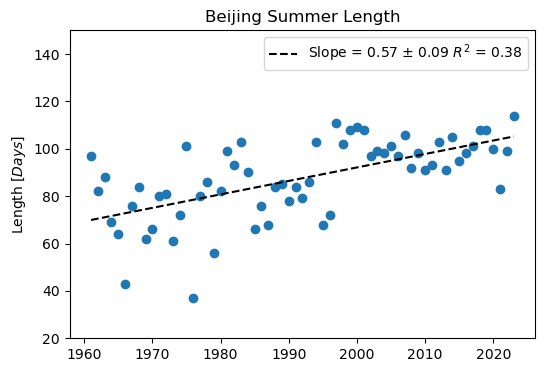

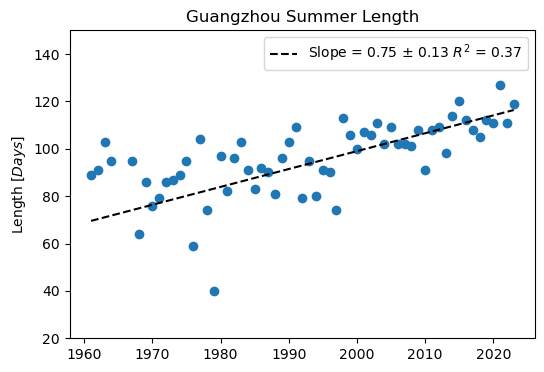

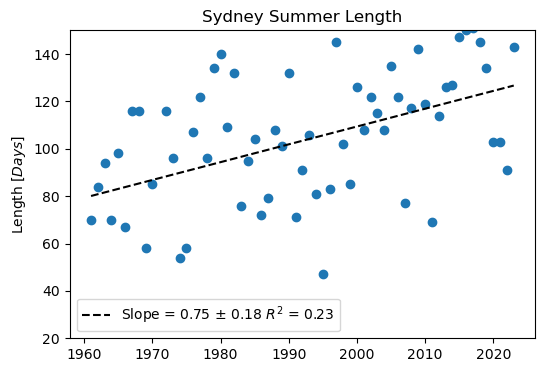

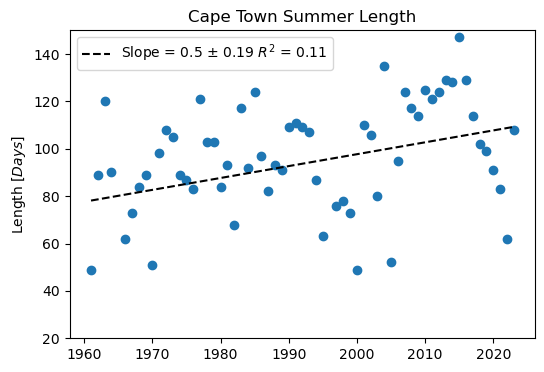

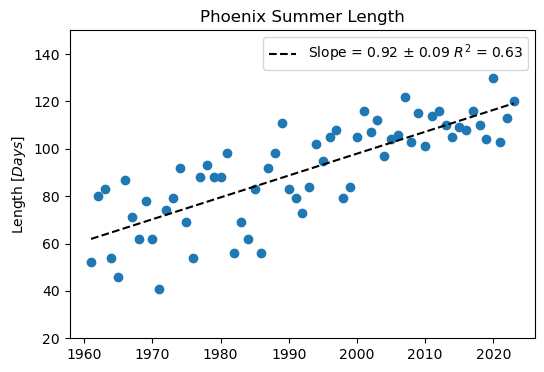

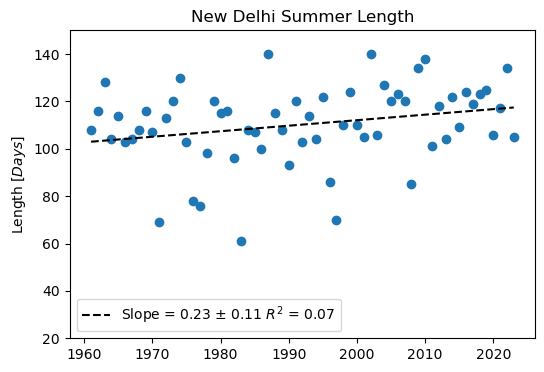

In [32]:

# Vancouver
input_lat = 49.246
input_lon = -123.116
van_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
van_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(van_length_analysis, van_length_base)
print("Van p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Vancouver w/ linear fit
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Vancouver Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# Toronto
# 43°45'03"N 79°28'55"W is roughly the middle from google earth
input_lat = 43 + 45/60
input_lon = -79 -29/60
tor_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
tor_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(tor_length_analysis, tor_length_base)
print("Tor p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Toronto
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Toronto Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# Beijing
input_lat = 39.9075
input_lon = 116.39723
bei_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
bei_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(bei_length_analysis, bei_length_base)
print("Bei p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Beijing
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Beijing Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)


# Guangzhou
# 112° 57′ to 114° 03′ E longitude and 22° 26′ to 23° 56′ N latitude
input_lat = 22 + 45/60 # midpoint of those latitude values above
input_lon = 113.5 # midpoint of those longitudes above
gua_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
gua_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(gua_length_analysis, gua_length_base)
print("Gua p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Guangzhou
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Guangzhou Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# Sydney, NSW
input_lat = -33.86785
input_lon = 151.083
syd_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
syd_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(syd_length_analysis, syd_length_base)
print("Syd p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Sydney
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Sydney Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# Cape Town
input_lat = -33.95
input_lon = 18+32/60
ctn_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
ctn_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(ctn_length_analysis, ctn_length_base)
print("CTn p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Cape Town
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Cape Town Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# Phoenix
input_lat = 33+28/60
input_lon = -112 - 4/60
phx_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
phx_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(phx_length_analysis, phx_length_base)
print("Phx p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Phoenix
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Phoenix Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# New Delhi
input_lat = 28+37/60
input_lon = 77 + 13/60
nwd_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
nwd_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(nwd_length_analysis, nwd_length_base)
print("NwD p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for New Delhi
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("New Delhi Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)


### The plots - 2 cities compared each time

#### Van vs Toronto

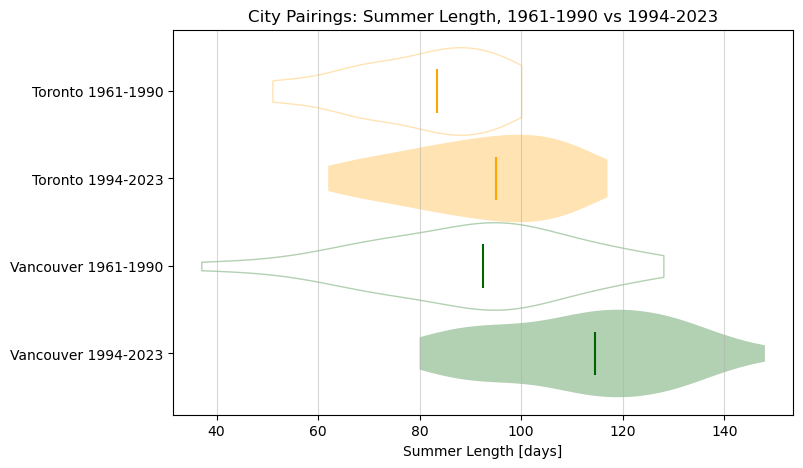

In [9]:
# violin plot customization from https://stackoverflow.com/questions/26291479/changing-the-color-of-matplotlibs-violin-plots
labels=['Vancouver 1994-2023','Vancouver 1961-1990',
        'Toronto 1994-2023','Toronto 1961-1990'
        ]

colors = ['darkgreen','darkgreen','orange','orange']#,'gray','gray','red','red','purple','purple']
data = [van_length_analysis, van_length_base, 
        tor_length_analysis, tor_length_base
       ]


fig, ax = plt.subplots(1, 1, figsize=(8,5))
plots = ax.violinplot(data, vert=False, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
    if i % 2 == 0:
        pc.set_facecolor(color)
    else:
        pc.set_edgecolor(color)
        pc.set_facecolor('white')

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_xlabel("Summer Length [days]")
ax.set_yticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="x", which='both', alpha=0.5)
plt.title("City Pairings: Summer Length, 1961-1990 vs 1994-2023")
plt.show()


In [16]:
print("Toronto Change in Median Summer Length: " + str(float(tor_length_analysis.median() - tor_length_base.median())) + " days")
print("Van Change in Median Summer Length: " + str(float(van_length_analysis.median() - van_length_base.median())) + " days")

Toronto Change in Median Summer Length: 11.5 days
Van Change in Median Summer Length: 22.0 days


#### Beijing vs Guangzhou

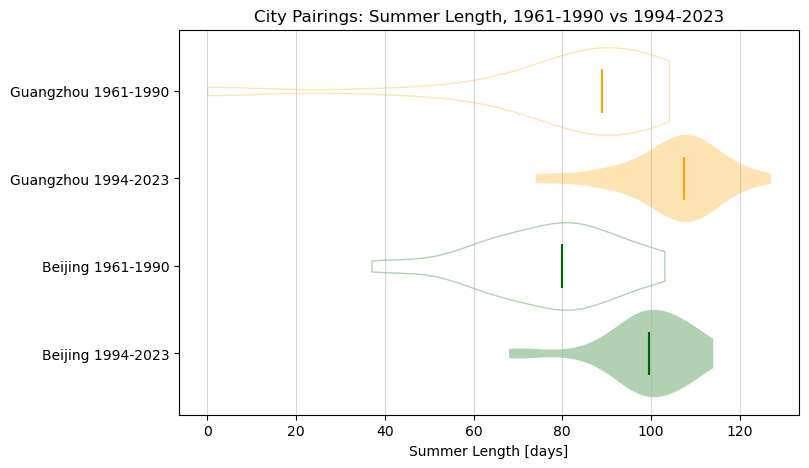

In [17]:
# violin plot customization from https://stackoverflow.com/questions/26291479/changing-the-color-of-matplotlibs-violin-plots
labels=['Beijing 1994-2023','Beijing 1961-1990',
        'Guangzhou 1994-2023','Guangzhou 1961-1990'
        ]

colors = ['darkgreen','darkgreen','orange','orange']#,'gray','gray','red','red','purple','purple']
data = [bei_length_analysis, bei_length_base, 
        gua_length_analysis, gua_length_base
       ]


fig, ax = plt.subplots(1, 1, figsize=(8,5))
plots = ax.violinplot(data, vert=False, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
    if i % 2 == 0:
        pc.set_facecolor(color)
    else:
        pc.set_edgecolor(color)
        pc.set_facecolor('white')

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_xlabel("Summer Length [days]")
ax.set_yticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="x", which='both', alpha=0.5)
plt.title("City Pairings: Summer Length, 1961-1990 vs 1994-2023")
plt.show()


In [18]:
print("Beijing Change in Median Summer Length: " + str(float(bei_length_analysis.median() - bei_length_base.median())) + " days")
print("Guangzhou Change in Median Summer Length: " + str(float(gua_length_analysis.median() - gua_length_base.median())) + " days")

Beijing Change in Median Summer Length: 19.5 days
Guangzhou Change in Median Summer Length: 18.5 days
